# Creating hardware native circuits

In this notebook we show the function to create hardware native circuits for the different graph types that we have defined in our instance library. The function `make_qaoa_circuit` is capable of creating optimized circuits for the following problem classes.

* Erdos-Renyi and random-regular graphs: perform a SAT mapping and a SWAP strategy on a line.
* Graphs built from a line plus a swap strategy: apply the line swap strategy.
* Heavy-hex: color the couploing map and apply the gates.

Furthermore, this function will select good qubits based on two-qubit gate fidelity.
This notebook shows how to use `make_qaoa_circuit` for the Maximum Independent Set problem and the Maxcut problem for the different types of graphs. For each graph type we show the routed cost-operator as a sanity check. 

In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService

from transpilation.make_qaoa_circuits import make_qaoa_circuit

In [2]:
service = QiskitRuntimeService(instance="optimization-premium-us")

In [3]:
backend = service.backend("ibm_kingston")

In [4]:
problem_classes = ["mis:20", "maxcut"]

## Erdos-Renyi graphs

In [5]:
file_name = "instances/erdos_renyi/000_10nodes_erdosrenyi20percent.json"

for problem_class in problem_classes:
    circuit, swap_circ = make_qaoa_circuit(file_name, problem_class, reps=1, backend=backend)
    print(circuit.count_ops(), circuit.depth(lambda x: len(x.qubits) == 2))

OrderedDict([('rz', 137), ('sx', 109), ('cz', 47), ('measure', 10)]) 13
OrderedDict([('rz', 118), ('sx', 101), ('cz', 47), ('measure', 10)]) 13


The `circuit` instance is the ISA circuit to run on the hardware. The `swap_circ` is a debug circuit to see how the cost operator was routed to the line of qubits. Note: in the circuit below there is an opportunity to locally optimize the SWAP network at the start of the circuit. This should be done in the best practices repository.

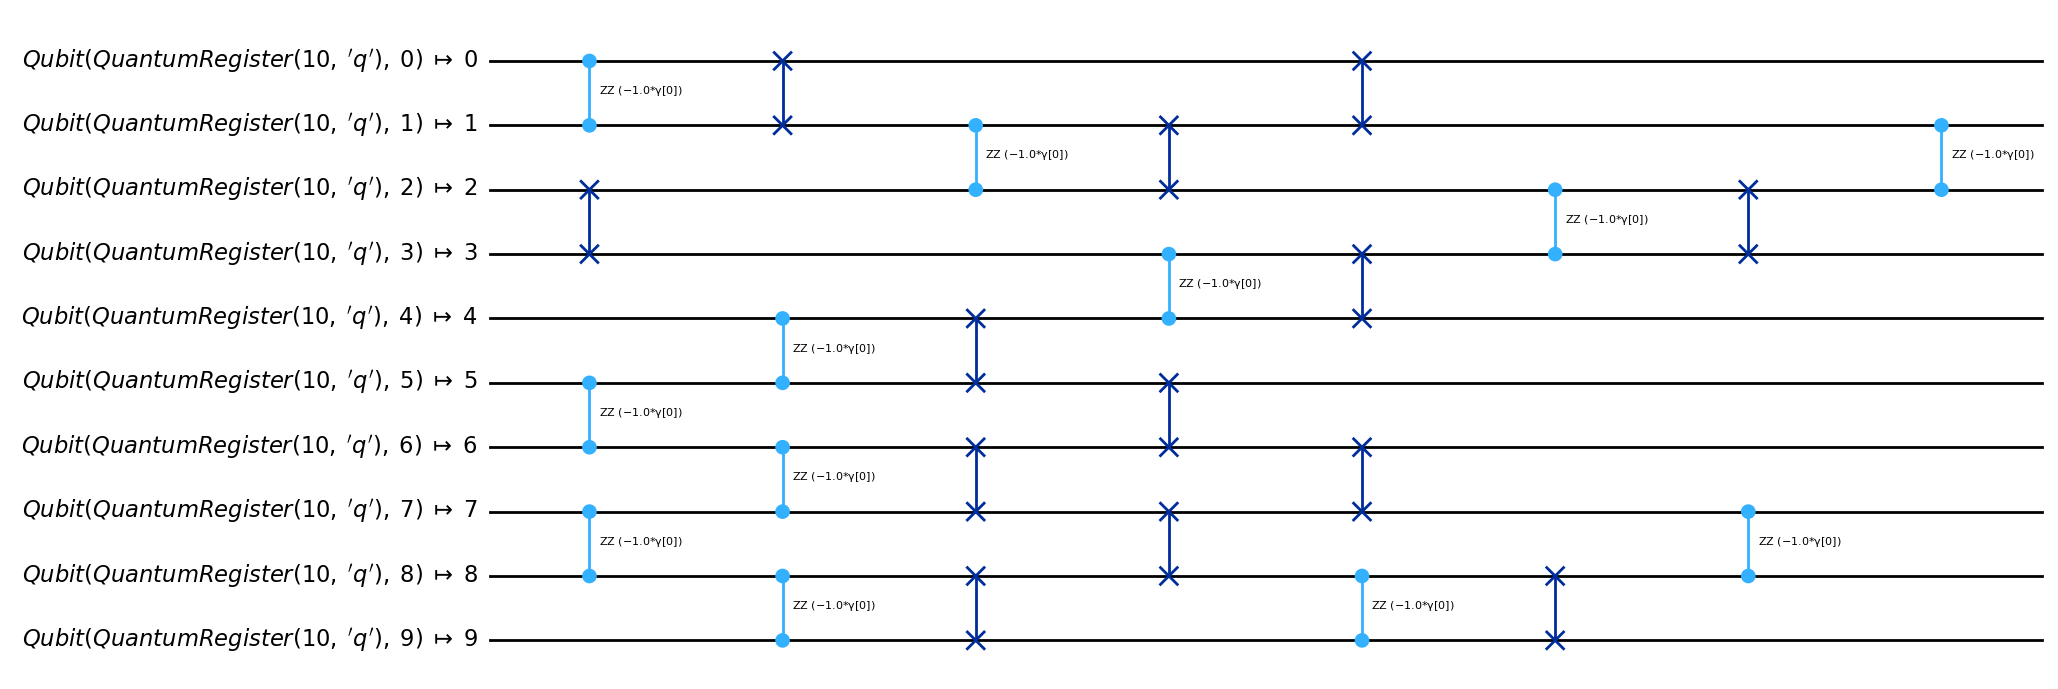

In [6]:
swap_circ.draw("mpl", idle_wires=False, fold=False, wire_order=None)

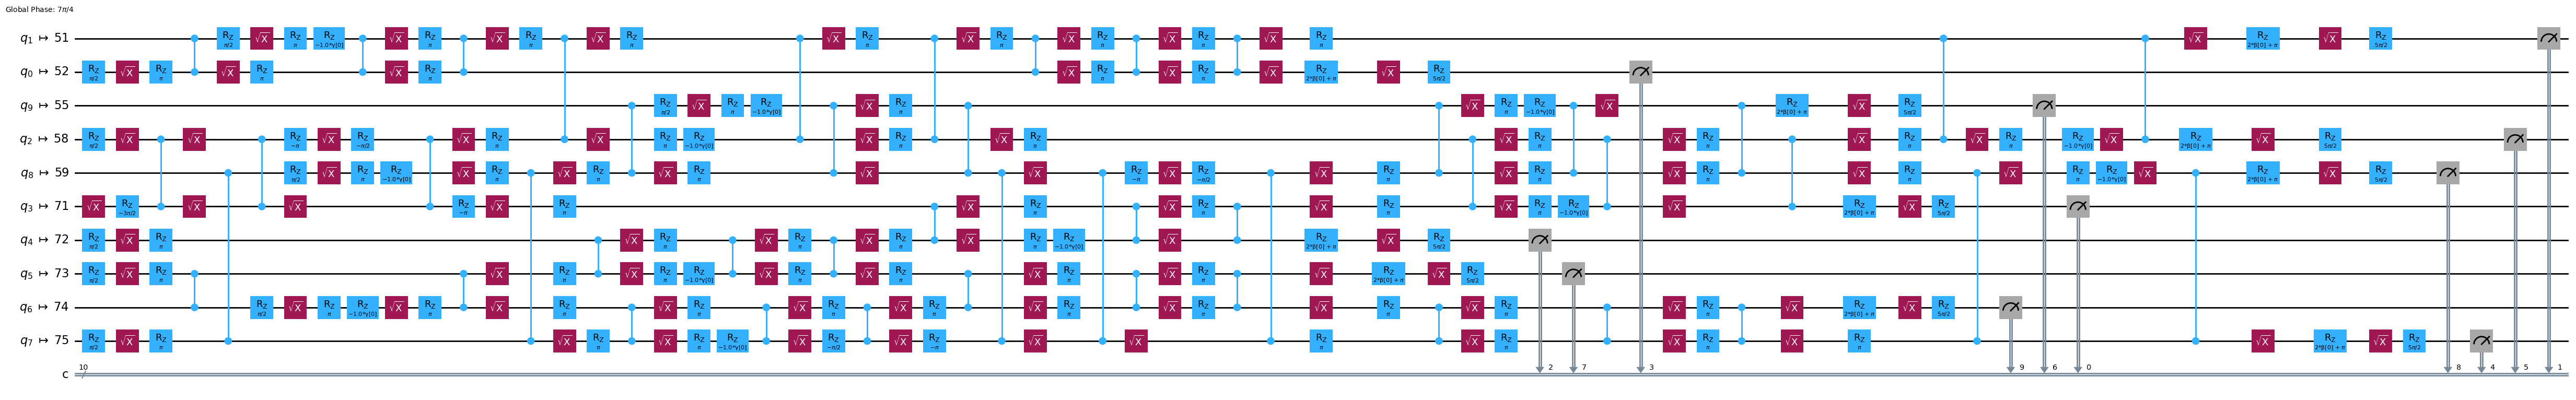

In [7]:
circuit.draw("mpl", idle_wires=False, fold=False, wire_order=None)

## Random regular graphs

In [8]:
file_name = "instances/random_regular/000_10nodes_random4regular.json"

for problem_class in problem_classes:
    circuit, swap_circ = make_qaoa_circuit(file_name, problem_class, reps=1, backend=backend)
    print(circuit.count_ops(), circuit.depth(lambda x: len(x.qubits) == 2))

OrderedDict([('rz', 175), ('sx', 141), ('cz', 64), ('measure', 10)]) 16
OrderedDict([('rz', 156), ('sx', 133), ('cz', 64), ('measure', 10)]) 16


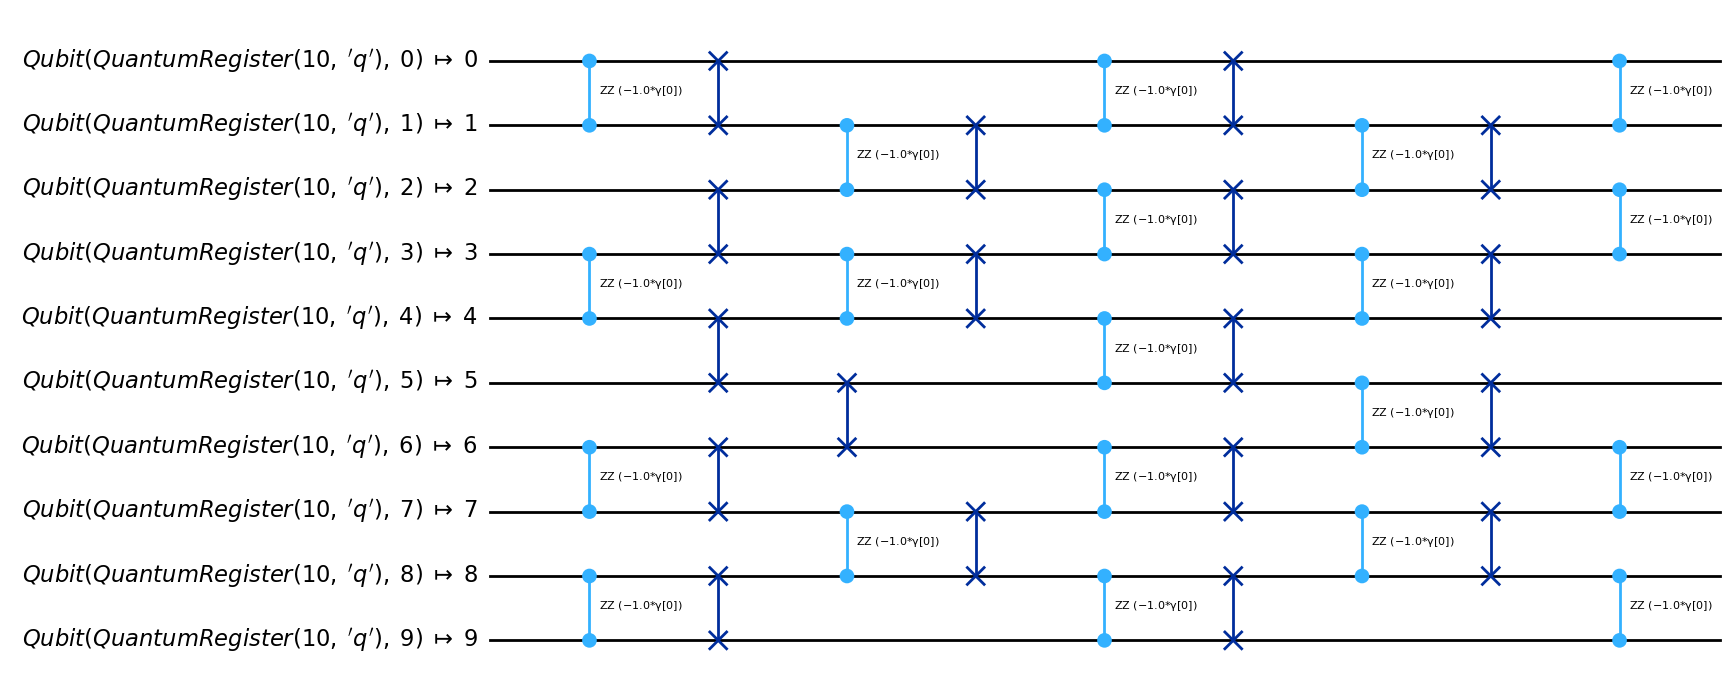

In [9]:
swap_circ.draw("mpl", idle_wires=False, fold=False, wire_order=None)

## Heavy-hex graphs

In [10]:
file_name = "instances/heavy_hex/000_2_1_heavyhex_21nodes_weighted.json"

for problem_class in problem_classes:
    circuit, swap_circ = make_qaoa_circuit(file_name, problem_class, reps=1, backend=backend)
    print(circuit.count_ops(), circuit.depth(lambda x: len(x.qubits) == 2))

OrderedDict([('rz', 171), ('sx', 107), ('cz', 44), ('measure', 21)]) 6
OrderedDict([('rz', 128), ('sx', 85), ('cz', 44), ('measure', 21)]) 6


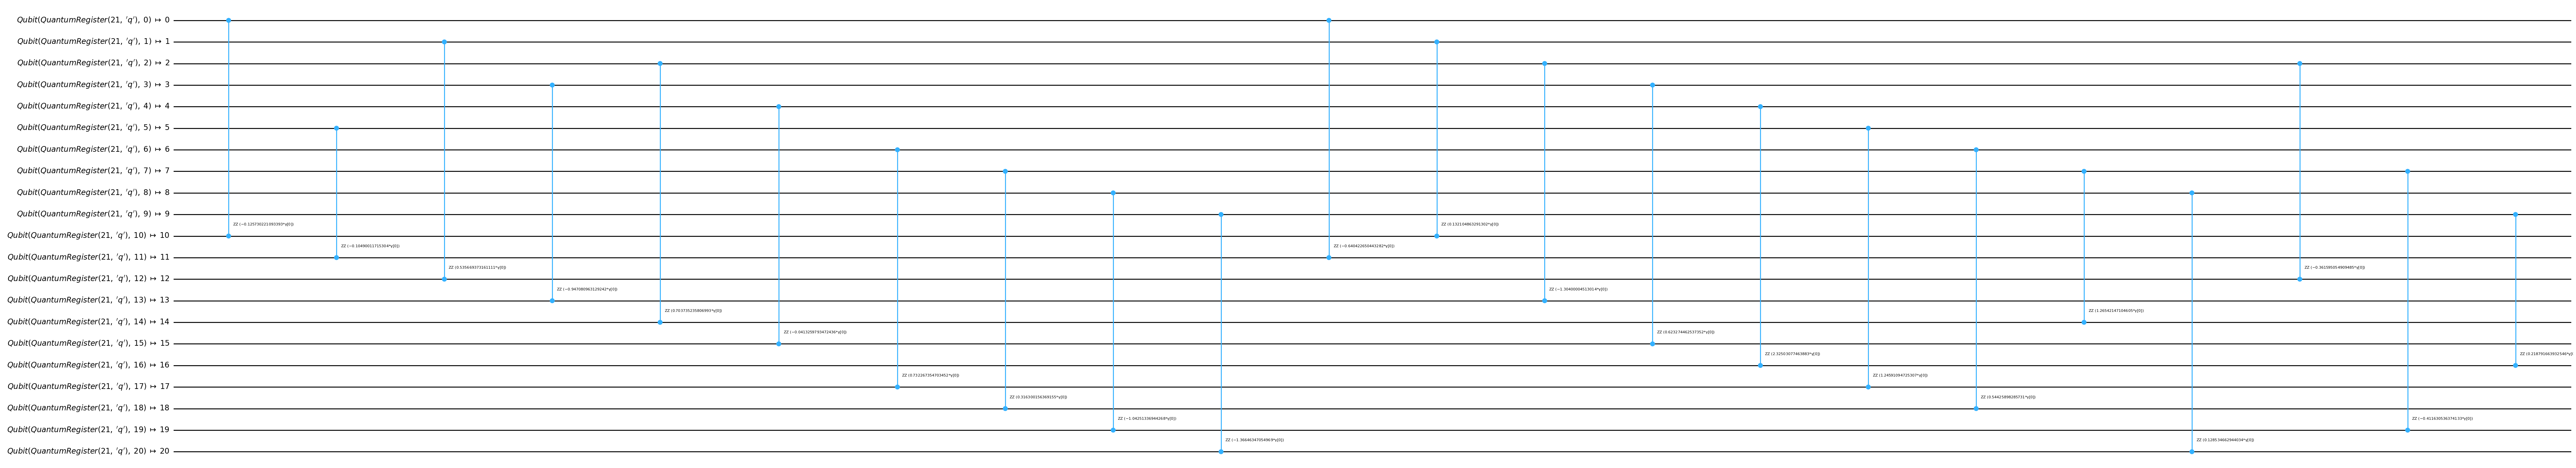

In [11]:
swap_circ.draw("mpl", idle_wires=False, fold=False, wire_order=None)

## Problems based on a line

In [12]:
file_name = "instances/line_to_full/000_10nodes_4swap_layers.json"

for problem_class in problem_classes:
    circuit, swap_circ = make_qaoa_circuit(file_name, problem_class, reps=1, backend=backend)
    print(circuit.count_ops(), circuit.depth(lambda x: len(x.qubits) == 2))

OrderedDict([('rz', 207), ('sx', 160), ('cz', 72), ('measure', 10)]) 16
OrderedDict([('rz', 187), ('sx', 150), ('cz', 72), ('measure', 10)]) 16


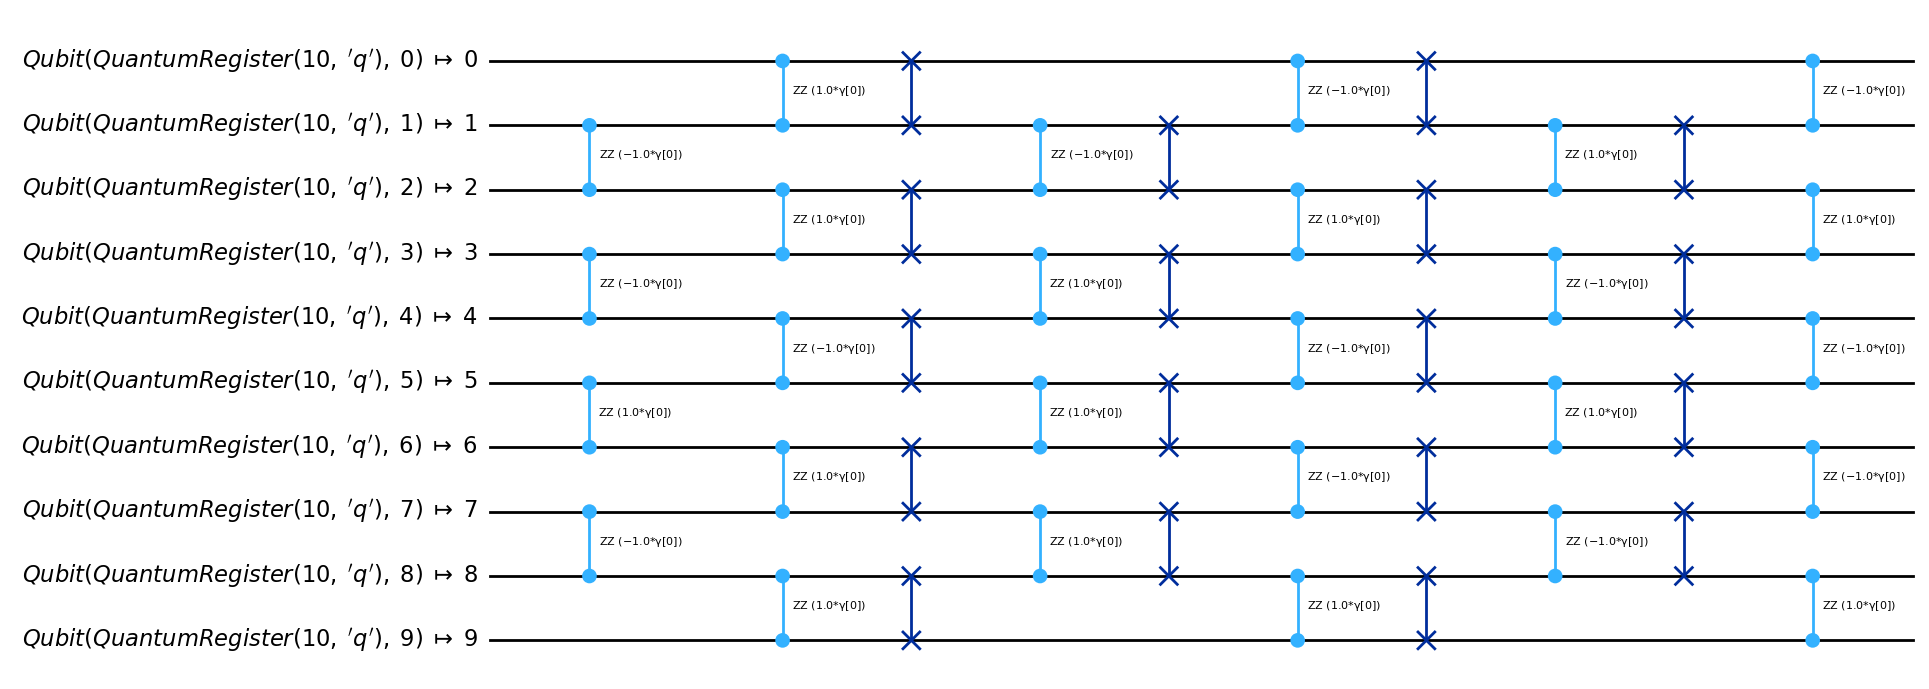

In [13]:
swap_circ.draw("mpl", idle_wires=False, fold=False, wire_order=None)

## Filter problem instances that make sense to run on Hardware

In the following cells we explore the problem instances that make sense to run on hardware. These instances must satisfy the constraints listed below.

* Beyond exact classical simulability. We place this threshold at 42 qubits.
* Beyond depth-one QAOA.
* The ISA circuits have less than 5k two-qubit gates.

 The NB gives an overview of which problems make sense to evaluate at what depth given the constraints above. We do this by printing the number of two-qubit CZ gates at QAOA depth-one. This requires transpiling the circuits to the hardware. Some of the cells below can take a significant amount of time to run since the SAT mapping may be used. We forego finding good lines of qubits since this can be very time-consuming and is irrelevant for computing gate counts.

In [4]:
import glob
import time

#### Erdos-Renyi

With SAT mapping we can do depth-two QAOA for 50 nodes Erdos-Renyi at 20% density and maybe 60 nodes which requires ~8k CZ gates.

In [9]:
erdos_renyi_circuits = dict()

sizes = [50]  #, 60, 70, 80, 90, 100]
percent = 20

for num_nodes in sizes:
    file_name = f"instances/erdos_renyi/000_{num_nodes}nodes_erdosrenyi{percent}percent.json"
    start = time.time()
    circuit, _ = make_qaoa_circuit(file_name, "maxcut", reps=1, backend=backend, sat_timeout=10, find_layout=False)
    print(file_name.split("\\")[-1], f"took {time.time()-start:.0f}sec and has", circuit.count_ops()["cz"], "CZ gates")
    erdos_renyi_circuits[file_name] = circuit

instances/erdos_renyi/000_50nodes_erdosrenyi20percent.json took 51sec and has 2667 CZ gates


From the above we see that the only Erdos-Renyi instances that make sense to attempt on hardware have a density of 20% and have 50 nodes.

#### Line-to-full

This class can be evaluated by hand. The depth is given by
\begin{align}
3\times (N_\text{SWAP}+1)\times\frac{n_{qubits}}{2}\times p
\end{align}


In [54]:
sizes = [50, 60, 70, 80, 90, 100]
qaoa_depth = 2

print(f"Meaningfull files to run at depth {qaoa_depth}")
for num_nodes in sizes:
    for file_name in glob.glob(f"instances/line_to_full/000_{num_nodes}nodes_*.json"):
        num_swaps = int(file_name.split("_")[4].replace("swap", ""))
        num_cz = int(3 * (num_swaps + 1) * num_nodes / 2 * qaoa_depth)
        if num_cz < 5000:
            print(file_name.split("line_to_full")[1][1:], f" has ~{num_cz} CZ gates")

Meaningfull files to run at depth 2
000_50nodes_0swap_layers.json  has ~150 CZ gates
000_50nodes_10swap_layers.json  has ~1650 CZ gates
000_50nodes_15swap_layers.json  has ~2400 CZ gates
000_50nodes_20swap_layers.json  has ~3150 CZ gates
000_50nodes_25swap_layers.json  has ~3900 CZ gates
000_50nodes_30swap_layers.json  has ~4650 CZ gates
000_50nodes_5swap_layers.json  has ~900 CZ gates
000_60nodes_0swap_layers.json  has ~180 CZ gates
000_60nodes_12swap_layers.json  has ~2340 CZ gates
000_60nodes_18swap_layers.json  has ~3420 CZ gates
000_60nodes_24swap_layers.json  has ~4500 CZ gates
000_60nodes_6swap_layers.json  has ~1260 CZ gates
000_70nodes_0swap_layers.json  has ~210 CZ gates
000_70nodes_14swap_layers.json  has ~3150 CZ gates
000_70nodes_21swap_layers.json  has ~4620 CZ gates
000_70nodes_7swap_layers.json  has ~1680 CZ gates
000_80nodes_0swap_layers.json  has ~240 CZ gates
000_80nodes_16swap_layers.json  has ~4080 CZ gates
000_80nodes_8swap_layers.json  has ~2160 CZ gates
000_90no

#### Random $k$-regular

100 nodes at depth-one R3R has 4575 CZ gates which is too much for larger depths. We are looking for depth-one graphs with < 2500 CZ gates. 80 nodes has 2973 CZ which might be on the limit. The table below reflects instances that we ran on hardware.

| Graph        | Depth-one gate count |   Make sense to run on hardware |
|--------------|----------------------|---------------------------------|
| R3R          |                      |                                 |
| R3R 80 nodes |                 2973 | Border line too deep at depth 2 |
| R3R 70 nodes |                 1365 |            Yes, up to depth 2-3 |
| R3R 60 nodes |                 1365 |              Yes, up to depth 3 |
| R3R 50 nodes |                 1000 |              Yes, up to depth 5 |
| R4R          |                      |                                 |
| R4R 70 nodes |                 3263 |                    No, too deep |
| R4R 60 nodes |                 2301 |              Yes, up to depth 2 |
| R4R 50 nodes |                 1538 |              Yes, up to depth 3 |
| Five regular |                      |                                 |
| R5R 60 nodes |                 2850 |              Yes, up to depth 2 |
| R5R 50 nodes |                 1859 |            Yes, up to depth 2-3 |
| Six regular  |                      |                                 |
| R6R 60 nodes |                 3021 | Border line too deep at depth 2 |
| R6R 50 nodes |                 2077 |              Yes, up to depth 2 |

In [18]:
rkr_circuits = dict()

sizes = [50]  # 80, 90, 100]
deg = 6

for num_nodes in sizes:
    file_name = f"instances/random_regular/000_{num_nodes}nodes_random{deg}regular.json"
    start = time.time()
    circuit, _ = make_qaoa_circuit(file_name, "maxcut", reps=1, backend=backend, sat_timeout=10, find_layout=False)
    print(f"{num_nodes} nodes with degree {deg} took {time.time() - start} seconds and has ", circuit.count_ops()["cz"], " CZs")
    rkr_circuits[file_name] = circuit

50 nodes with degree 6 took 40.364033460617065 seconds and has  2077  CZs


In [11]:
for file_name, circ in rkr_circuits.items():
    print(circ.count_ops()["cz"])

1538


#### Heavy-hex

We can execute all instances up to a depth of 10.

In [7]:
import warnings

warnings.filterwarnings("ignore")

In [8]:
for file_name in glob.glob(f"instances/heavy_hex/000_*.json"):
    start = time.time()
    circuit, _ = make_qaoa_circuit(file_name, "maxcut", reps=1, backend=backend, sat_timeout=10, meas_threshold=0.0)
    print(file_name.split("\\")[-1], f"took {time.time()-start:.0f}sec and has", circuit.count_ops()["cz"], "CZ gates")

000_1_1_heavyhex_12nodes_weighted.json took 1sec and has 24 CZ gates
000_1_2_heavyhex_21nodes_weighted.json took 1sec and has 44 CZ gates
000_1_3_heavyhex_30nodes_weighted.json took 1sec and has 64 CZ gates
000_2_1_heavyhex_21nodes_weighted.json took 1sec and has 44 CZ gates
000_2_2_heavyhex_35nodes_weighted.json took 1sec and has 76 CZ gates
000_2_3_heavyhex_49nodes_weighted.json took 1sec and has 108 CZ gates
000_3_1_heavyhex_30nodes_weighted.json took 1sec and has 64 CZ gates
000_3_2_heavyhex_49nodes_weighted.json took 2sec and has 108 CZ gates
000_3_3_heavyhex_68nodes_weighted.json took 2sec and has 152 CZ gates
000_4_1_heavyhex_39nodes_weighted.json took 2sec and has 84 CZ gates
000_4_2_heavyhex_63nodes_weighted.json took 2sec and has 140 CZ gates
000_4_3_heavyhex_87nodes_weighted.json took 2sec and has 196 CZ gates
000_5_1_heavyhex_48nodes_weighted.json took 2sec and has 104 CZ gates
000_5_2_heavyhex_77nodes_weighted.json took 2sec and has 172 CZ gates
000_5_3_heavyhex_106nodes_w

Based on the results above, we can execute all heavy-hex instances up to the maximum QAOA depth of 10 that we care about.